<a href="https://colab.research.google.com/github/SeratAftab131/Ocular-Disease-Prediction/blob/main/Ocular_disease_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Verification and Environment Set-Up

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
from PIL import Image

train_dir = '/content/drive/MyDrive/Thesis/ODIR-5K/ODIR-5K/Training Images'
test_dir  = '/content/drive/MyDrive/Thesis/ODIR-5K/ODIR-5K/Testing Images'
pre_dir   = '/content/drive/MyDrive/Thesis/preprocessed_images'
csv_path  = '/content/drive/MyDrive/Thesis/full_df.csv'

df = pd.read_csv(csv_path)
print("=== CSV ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Label columns sample:")
print(df[['filename','N','D','G','C','A','H','M','O']].head(5).to_string())

for label, path in [('Training Images', train_dir),
                    ('Testing Images',  test_dir),
                    ('preprocessed',    pre_dir)]:
    files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"\n=== {label}: {len(files)} images ===")
    sizes = set()
    for f in files[:10]:
        img = Image.open(os.path.join(path, f))
        sizes.add(img.size)
    print(f"  Unique sizes in first 10: {sizes}")
    arr = np.array(Image.open(os.path.join(path, files[0])))
    print(f"  Pixel range: {arr.min()} – {arr.max()}")
    print(f"  Sample filenames: {files[:3]}")

train_files = set(os.listdir(train_dir))
matched = df['filename'].isin(train_files).sum()
print(f"\n=== Filename match: {matched}/{len(df)} CSV filenames found in Training Images ===")

Mounted at /content/drive
=== CSV ===
Shape: (6392, 19)
Missing values: 0
Duplicates: 0
Label columns sample:
      filename  N  D  G  C  A  H  M  O
0  0_right.jpg  0  0  0  1  0  0  0  0
1  1_right.jpg  1  0  0  0  0  0  0  0
2  2_right.jpg  0  1  0  0  0  0  0  1
3  4_right.jpg  0  1  0  0  0  0  0  1
4  5_right.jpg  0  1  0  0  0  0  0  0

=== Training Images: 7000 images ===
  Unique sizes in first 10: {(2048, 1536), (1380, 1382), (2592, 1944), (2460, 1904), (2304, 1728), (2592, 1728), (1624, 1232), (1920, 1296)}
  Pixel range: 0 – 255
  Sample filenames: ['542_left.jpg', '554_right.jpg', '552_right.jpg']

=== Testing Images: 1000 images ===
  Unique sizes in first 10: {(1936, 1296), (2048, 1536), (2592, 1728)}
  Pixel range: 0 – 251
  Sample filenames: ['1000_right.jpg', '1000_left.jpg', '1001_left.jpg']

=== preprocessed: 6392 images ===
  Unique sizes in first 10: {(512, 512)}
  Pixel range: 0 – 254
  Sample filenames: ['4635_left.jpg', '545_right.jpg', '576_right.jpg']

=== Fil

# Data Analysis

/tmp/ipykernel_1278/4262207488.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(disease_names, rotation=25, ha='right')


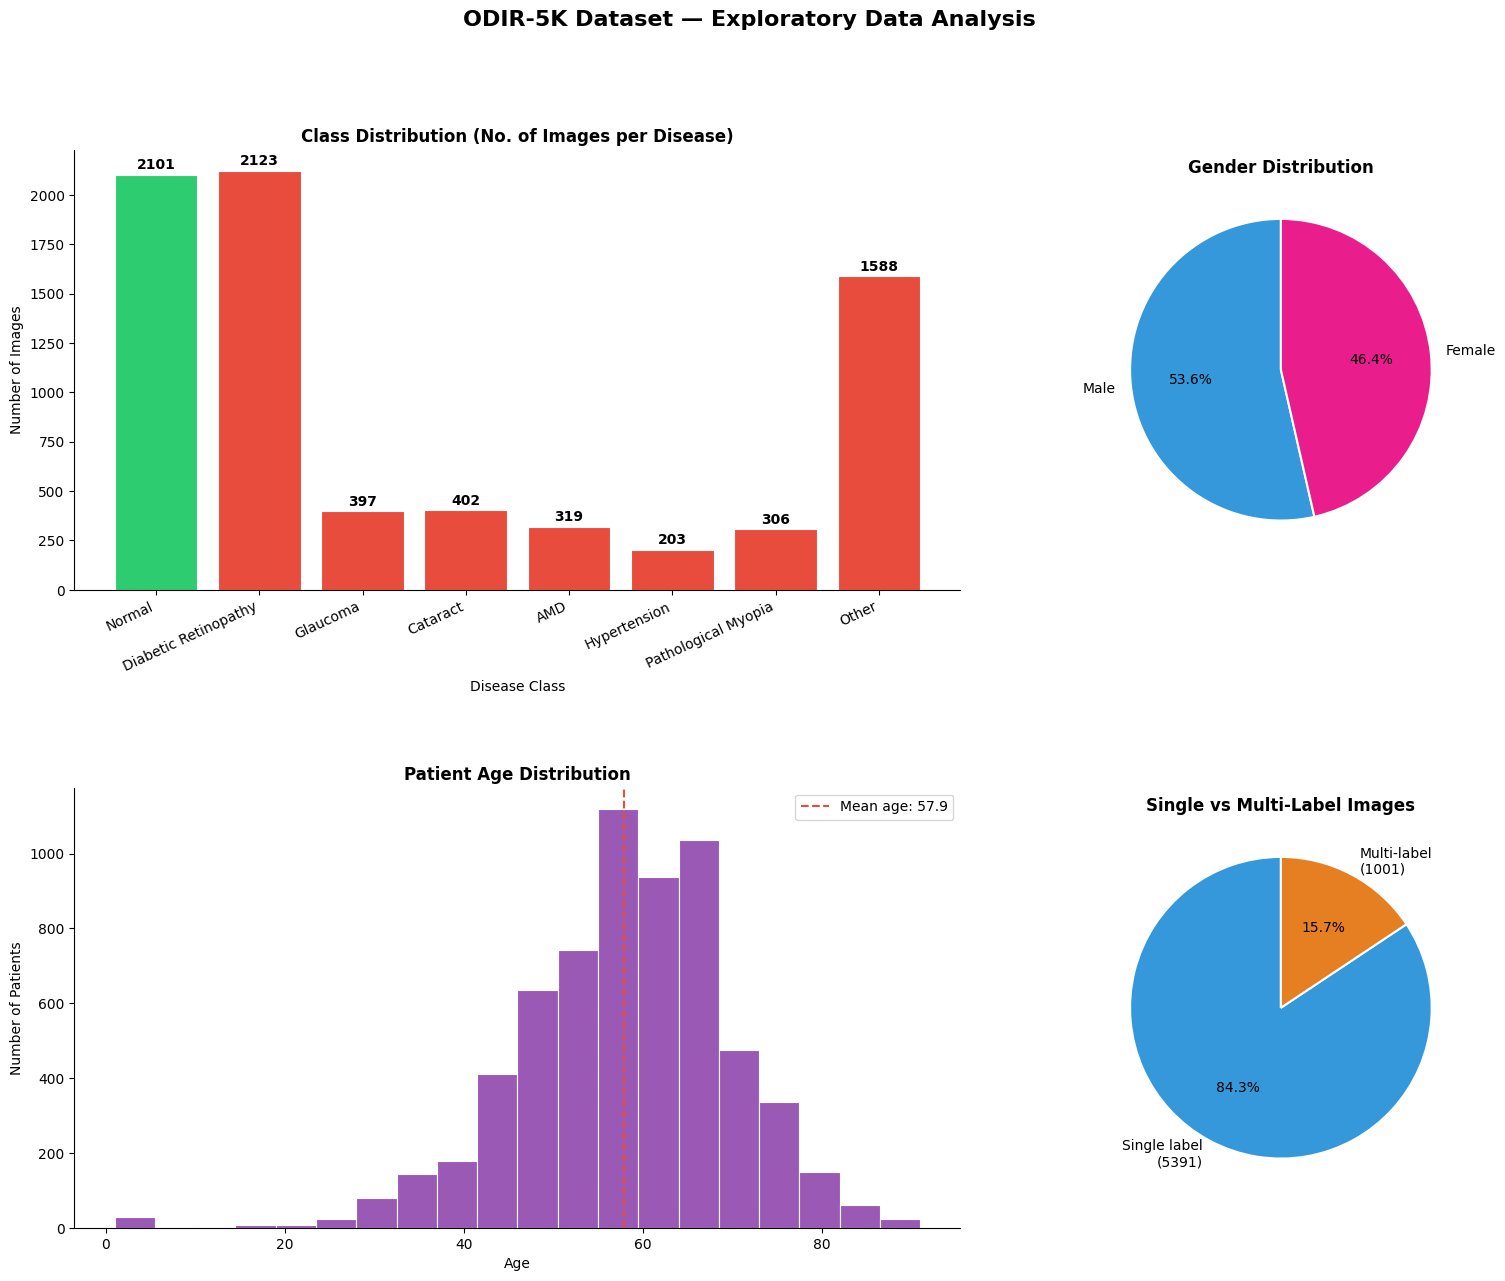

=== Dataset Summary ===
Total images       : 6392
Multi-label images : 1001 (15.7%)
Single-label images: 5391 (84.3%)

Class counts:
  Normal                   : 2101
  Diabetic Retinopathy     : 2123
  Glaucoma                 : 397
  Cataract                 : 402
  AMD                      : 319
  Hypertension             : 203
  Pathological Myopia      : 306
  Other                    : 1588

Age — mean: 57.9, min: 1, max: 91

Gender:
Patient Sex
Male      3424
Female    2968


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df = pd.read_csv(csv_path)

disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertension', 'Pathological Myopia', 'Other']

class_counts   = df[disease_cols].sum().values
multi_label    = (df[disease_cols].sum(axis=1) > 1).sum()
single_label   = len(df) - multi_label
gender_counts  = df['Patient Sex'].value_counts()

fig = plt.figure(figsize=(18, 14))
fig.suptitle('ODIR-5K Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
colors = ['#2ecc71' if n == 'Normal' else '#e74c3c' for n in disease_names]
bars = ax1.bar(disease_names, class_counts, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Class Distribution (No. of Images per Disease)', fontweight='bold')
ax1.set_xlabel('Disease Class')
ax1.set_ylabel('Number of Images')
ax1.set_xticklabels(disease_names, rotation=25, ha='right')
for bar, count in zip(bars, class_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        colors=['#3498db','#e91e8c'],
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax2.set_title('Gender Distribution', fontweight='bold')

ax3 = fig.add_subplot(gs[1, :2])
ax3.hist(df['Patient Age'], bins=20, color='#9b59b6', edgecolor='white', linewidth=0.8)
ax3.set_title('Patient Age Distribution', fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Number of Patients')
ax3.axvline(df['Patient Age'].mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f"Mean age: {df['Patient Age'].mean():.1f}")
ax3.legend()
ax3.spines[['top','right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 2])
ax4.pie([single_label, multi_label],
        labels=[f'Single label\n({single_label})', f'Multi-label\n({multi_label})'],
        autopct='%1.1f%%',
        colors=['#3498db','#e67e22'],
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax4.set_title('Single vs Multi-Label Images', fontweight='bold')

plt.savefig('/content/drive/MyDrive/Thesis/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Dataset Summary ===")
print(f"Total images       : {len(df)}")
print(f"Multi-label images : {multi_label} ({multi_label/len(df)*100:.1f}%)")
print(f"Single-label images: {single_label} ({single_label/len(df)*100:.1f}%)")
print(f"\nClass counts:")
for name, count in zip(disease_names, class_counts):
    print(f"  {name:<25}: {count}")
print(f"\nAge — mean: {df['Patient Age'].mean():.1f}, "
      f"min: {df['Patient Age'].min()}, max: {df['Patient Age'].max()}")
print(f"\nGender:\n{gender_counts.to_string()}")

# Data Generator & Preprocessing Pipeline

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pre_dir  = '/content/drive/MyDrive/Thesis/preprocessed_images'
csv_path = '/content/drive/MyDrive/Thesis/full_df.csv'

df = pd.read_csv(csv_path)

disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

df['full_path'] = df['filename'].apply(lambda x: os.path.join(pre_dir, x))
missing = df[~df['full_path'].apply(os.path.exists)]
print(f"Missing images: {len(missing)}")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['D']
)
print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")

def create_generator(dataframe, image_dir, batch_size=32,
                     target_size=(224, 224), augment=False, shuffle=True):

    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15      if augment else 0,
        horizontal_flip=True   if augment else False,
        zoom_range=0.1         if augment else 0,
        brightness_range=[0.8, 1.2] if augment else None,
    )

    generator = datagen.flow_from_dataframe(
        dataframe=dataframe,
        directory=image_dir,
        x_col='filename',
        y_col=disease_cols,
        class_mode='raw',
        target_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
    )
    return generator

train_gen = create_generator(train_df, pre_dir, augment=True,  shuffle=True)
val_gen   = create_generator(val_df,   pre_dir, augment=False, shuffle=False)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")

images, labels = next(train_gen)
print(f"\nBatch image shape : {images.shape}")
print(f"Batch label shape : {labels.shape}")
print(f"Pixel range       : {images.min():.2f} – {images.max():.2f}")
print(f"Sample label      : {labels[0]}")

total = len(train_df)
class_weights = {}
for i, col in enumerate(disease_cols):
    pos = train_df[col].sum()
    neg = total - pos
    class_weights[i] = round(neg / (pos + 1e-6), 2)

print("\nClass weights (higher = rarer class):")
for col, w in zip(disease_cols, class_weights.values()):
    print(f"  {col} : {w}")

Missing images: 0
Train size : 5113
Val size   : 1279
Found 5113 validated image filenames.
Found 1279 validated image filenames.

Train batches : 160
Val batches   : 40

Batch image shape : (32, 224, 224, 3)
Batch label shape : (32, 8)
Pixel range       : 0.00 – 1.00
Sample label      : [1 0 0 0 0 0 0 0]

Class weights (higher = rarer class):
  N : 2.05
  D : 2.01
  G : 15.65
  C : 15.28
  A : 18.15
  H : 33.09
  M : 20.85
  O : 3.0


# 	Disease Co-occurrence Analysis

=== Co-occurrence Matrix ===
   N    D   G   C   A   H   M    O
N  0    0   0   0   0   0   0    0
D  0    0  56  74  32  89  36  497
G  0   56   0   6  20  15  13   78
C  0   74   6   0   0   4   0   56
A  0   32  20   0   0   8   4   26
H  0   89  15   4   8   0   0   21
M  0   36  13   0   4   0   0   58
O  0  497  78  56  26  21  58    0

=== Top Co-occurring Disease Pairs ===
   Disease 1 Disease 2  Count
0          D         O    497
1          D         H     89
2          G         O     78
3          D         C     74
4          M         O     58
5          D         G     56
6          C         O     56
7          D         M     36
8          D         A     32
9          A         O     26
10         H         O     21
11         G         A     20
12         G         H     15
13         G         M     13
14         A         H      8
15         G         C      6
16         C         H      4
17         A         M      4


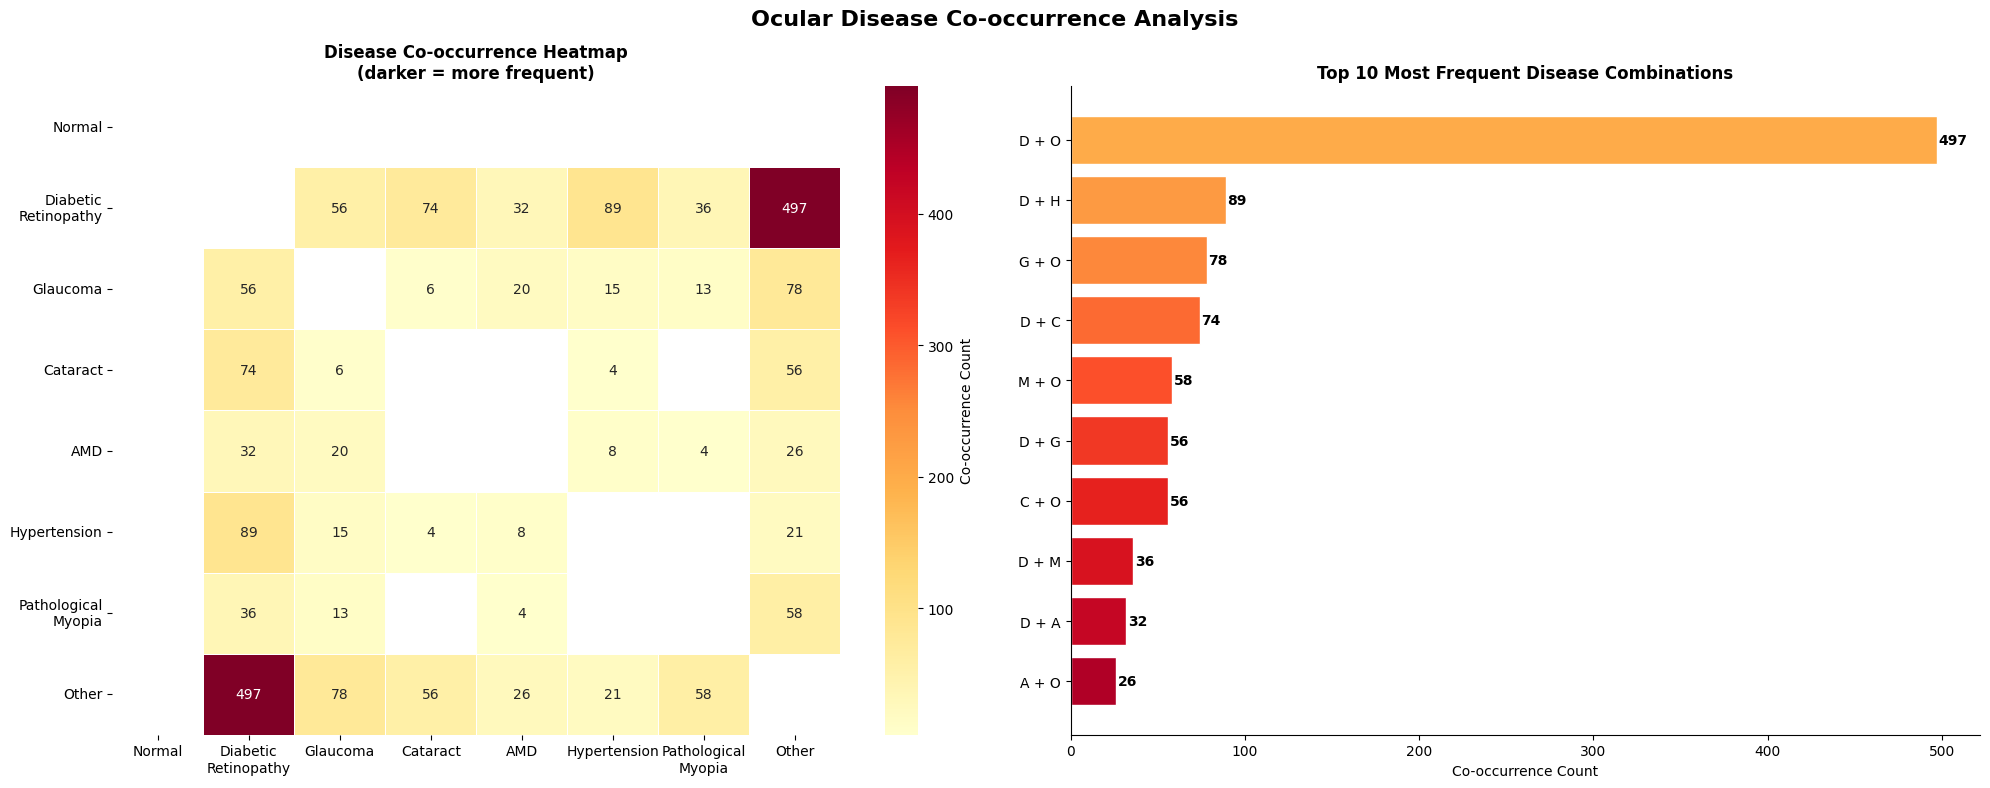


=== Key Insights ===
Total multi-label images     : 1001
Total unique co-occurring pairs found : 18

Most frequent pair : D + O (497 images)
Least frequent pair: A + M (4 images)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

csv_path = '/content/drive/MyDrive/Thesis/full_df.csv'
df = pd.read_csv(csv_path)

disease_cols  = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = ['Normal', 'Diabetic\nRetinopathy', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertension', 'Pathological\nMyopia', 'Other']

co_matrix = pd.DataFrame(np.zeros((8, 8), dtype=int),
                         index=disease_cols,
                         columns=disease_cols)

for _, row in df.iterrows():
    diseases = [col for col in disease_cols if row[col] == 1]
    for d1, d2 in combinations(diseases, 2):
        co_matrix.loc[d1, d2] += 1
        co_matrix.loc[d2, d1] += 1

print("=== Co-occurrence Matrix ===")
print(co_matrix.to_string())

pairs = []
for d1, d2 in combinations(disease_cols, 2):
    count = co_matrix.loc[d1, d2]
    if count > 0:
        pairs.append((d1, d2, count))

pairs_df = pd.DataFrame(pairs, columns=['Disease 1', 'Disease 2', 'Count'])
pairs_df = pairs_df.sort_values('Count', ascending=False).reset_index(drop=True)

print("\n=== Top Co-occurring Disease Pairs ===")
print(pairs_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Ocular Disease Co-occurrence Analysis', fontsize=16, fontweight='bold')

mask = co_matrix == 0
sns.heatmap(co_matrix,
            ax=axes[0],
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            xticklabels=disease_names,
            yticklabels=disease_names,
            linewidths=0.5,
            linecolor='white',
            mask=mask,
            cbar_kws={'label': 'Co-occurrence Count'})
axes[0].set_title('Disease Co-occurrence Heatmap\n(darker = more frequent)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

top_pairs = pairs_df.head(10)
pair_labels = [f"{r['Disease 1']} + {r['Disease 2']}" for _, r in top_pairs.iterrows()]
bar_colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_pairs)))
bars = axes[1].barh(pair_labels[::-1], top_pairs['Count'].values[::-1],
                    color=bar_colors[::-1], edgecolor='white')
axes[1].set_title('Top 10 Most Frequent Disease Combinations', fontweight='bold')
axes[1].set_xlabel('Co-occurrence Count')
for bar, count in zip(bars, top_pairs['Count'].values[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(count), va='center', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Thesis/co_occurrence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Key Insights ===")
print(f"Total multi-label images     : {(df[disease_cols].sum(axis=1) > 1).sum()}")
print(f"Total unique co-occurring pairs found : {len(pairs_df)}")
print(f"\nMost frequent pair : {pairs_df.iloc[0]['Disease 1']} + "
      f"{pairs_df.iloc[0]['Disease 2']} ({pairs_df.iloc[0]['Count']} images)")
print(f"Least frequent pair: {pairs_df.iloc[-1]['Disease 1']} + "
      f"{pairs_df.iloc[-1]['Disease 2']} ({pairs_df.iloc[-1]['Count']} images)")